In [1]:
import pandas as pd

from src.dependencies import *
from harmonize.hm_supplier_config import detect_supplier
from harmonize.hm_import_data import *
from harmonize.supplier_support_func.hm_gen_trans_func import *
from src.paths import PATHS_OBJ

# -------------------- Initialise paths --------------------------------
base_path = PATHS_OBJ.base_path
dump_path = PATHS_OBJ.dump_path
extract_path = PATHS_OBJ.extract_path
harmonized_folder = PATHS_OBJ.harmonized_path
config_path = PATHS_OBJ.config_path
config_file_path = PATHS_OBJ.config_file_path
logs_path = PATHS_OBJ.logs_path
backlog_path = PATHS_OBJ.backlog_path
debug_path = PATHS_OBJ.debug_path
backend_path = PATHS_OBJ.backend_path

etl_config_path = PATHS_OBJ.ETL_config_path
etl_df = pd.read_excel(etl_config_path,sheet_name='config')

In [2]:
sz_data_path = Path(r"//vw.vwg/vwdfs/PowerCo/Salzgitter/0560-datashare/02_RawData/096/096_006_P/")
Chosen_CellIDs = ["096_006_P_012", "096_006_P_013", "096_006_P_014", "096_006_P_015"]

hm_status_dict = defaultdict(dict)

extracted_files_paths = list(sz_data_path.rglob('*dyn.csv'))
extracted_files_paths = [file for file in extracted_files_paths if file.parent.stem in Chosen_CellIDs]

config_name,_ = find_matching_config(file_path=extracted_files_paths[0],etl_df=etl_df, hm_status_dict=hm_status_dict)
config_selected = etl_df[etl_df['Config_id']==config_name].iloc[0]
raw_data = pd.read_csv(extracted_files_paths[0],encoding="ISO-8859-1", sep=';', skiprows=[1])
gen_clean_datasheet(sheet_df=raw_data,
                                     config_selected=config_selected,
                                     focus_cols=FOCUS_COLS_ETL,
                                     mandatory_cols=MANDATORY_COLS_ETL)

C:\Users\WYBT00P\PycharmProjects\TB_CPA_TestDataAutomation\TB_CPA_TestDataAutomation\harmonize\hm_import_data.py:226: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match_configs_df['sheet_match_flg'] = False


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [4]:

pd.isna("s")

False

### MCM time series function

In [47]:
file_path = Path(r"C:\Users\WYBT00P\OneDrive - Volkswagen AG\C48 Test data - C48T1\Testing_DataBase\x_DataHandling\B2_sample\02_Extracted_Raw_Files\GOT0006\GOT0006#-10D-18s-5-40soc-Arbitrary file name 2025-09-09 21-53-37_443.005.XLS")

cfg_cls = cfg_mcm_xls_01(file_path)

df = cfg_cls.get_raw_data(etl_df[etl_df['Config_id']=="cfg_mcm_xls_01"].iloc[0])
df

3,Rec,Cycle P,Cycle C,Step,Test Time,Step Time,Capacity (AHr),Energy,Current,Power,...,MD,ES,DPT Time,AUX1 [C],AUX2 [C],AUX3 [C],AUX4 [C],VAR1,VAR2,VAR3
0,1,0,1,1,0d 00:00:0,0d 00:00:0.00,0.0,0.0,0.0,0,...,R,0,2025/9/9 21:53,24.52,24.23,24.15,24.43,0,0.0000,0.0000
1,2,0,1,1,0d 00:00:0,0d 00:00:0.01,0.0,0.0,0.0,0,...,R,1,2025/9/9 21:53,24.52,24.23,24.15,24.43,0,0.0000,0.0000
2,3,0,1,1,0d 00:00:30,0d 00:00:30.00,0.0,0.0,0.0,0,...,R,1,2025/9/9 21:54,24.55,24.24,24.18,24.48,0,0.0000,0.0000
3,4,0,1,1,0d 00:00:60,0d 00:00:60.00,0.0,0.0,0.0,0,...,R,1,2025/9/9 21:54,24.57,24.26,24.19,24.49,0,0.0000,0.0000
4,5,0,1,1,0d 00:01:30,0d 00:01:30.00,0.0,0.0,0.0,0,...,R,1,2025/9/9 21:55,24.58,24.26,24.19,24.53,0,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172765,"""172,766""",0,9,69,1d 02:00:29,0d 00:29:59.70,0.0,0.0,0.0,0,...,R,1,2025/9/11 10:21,10.38,10.12,10.13,9.74,0,0.9794,1.1454
172766,"""172,767""",0,9,69,1d 02:00:30,0d 00:29:59.80,0.0,0.0,0.0,0,...,R,1,2025/9/11 10:21,10.38,10.12,10.13,9.74,0,0.9794,1.1454
172767,"""172,768""",0,9,69,1d 02:00:30,0d 00:29:59.90,0.0,0.0,0.0,0,...,R,1,2025/9/11 10:21,10.38,10.12,10.13,9.74,0,0.9794,1.1454
172768,"""172,769""",0,9,69,1d 02:00:30,0d 00:29:60.00,0.0,0.0,0.0,0,...,R,129,2025/9/11 10:21,10.38,10.12,10.13,9.74,0,0.9794,1.1454


In [109]:
def mcm_transform_reltime(file_df:pd.DataFrame, input_column:list[str]) -> pd.Series|None:
    # input_columns = ["Test Time","Step Time"]
    # input format 0d 08:47:57.31, uses both columns to create a step time, assuming step time has better time resolution

    try:
        if (len(input_column)>1) and (input_column[0] in file_df.columns) and (input_column[1] in file_df.columns):
            test_time = pd.to_timedelta(file_df[input_column[0]]).dt.total_seconds().copy()
            step_time = pd.to_timedelta(file_df[input_column[1]]).dt.total_seconds().copy()

            delta_test_time = test_time.diff()
            delta_step_time = step_time.diff()
            delta_step_time[delta_step_time < 0] = 0

            mask = delta_test_time == 0
            for i in test_time.loc[mask].index:
                test_time.at[i] = test_time.at[i-1] + delta_step_time.at[i]

            return test_time.round(3)

        elif (input_column[0] in file_df.columns):
            test_time = pd.to_timedelta(file_df[input_column[0]]).dt.total_seconds().copy()
            return test_time.round(3)
    except:
        return None

def mcm_transform_unixtime(file_df:pd.DataFrame, input_columns:list[str])-> pd.Series|None:
    # input 0 is datetime and input 1 is Test time, input 2 is Step time
    # All inputs are in datetime format
    # Tries to pick the first time stamp and add the total seconds to the timestamp

    DPT_Time = pd.to_datetime(file_df[input_columns[0]], errors='coerce')
    if (len(input_columns)>1):
        # try to add timedelta and total seconds caluclated from mcm_transform_reltime() - which considers steptime
        if (input_columns[0] in input_columns) and (input_columns[1] in input_columns):
            test_time = mcm_transform_reltime(file_df, input_columns[1:]) # total test time in seconds
            rel_time_delta = test_time.diff()  # relative time delta
            abs_time_delta = (DPT_Time - DPT_Time.iloc[0]).dt.total_seconds().diff() #absolute time delta

            for indx in rel_time_delta.loc[(abs_time_delta - rel_time_delta) > 60].index:
                test_time.loc[indx:] = test_time.loc[indx:] + abs_time_delta.loc[indx]

            timeser = DPT_Time.iloc[0] + pd.to_timedelta(test_time, 's')

            if (pd.to_datetime(file_df[input_columns[0]]).iloc[-1] - timeser.iloc[-1]).total_seconds() < 60:
                return timeser
            else:
                logging.info(f"Note @mcm_transform_unixtime() - mismatch in last datetime value, rather using only {input_columns[0]}")

    timeser = pd.to_datetime(file_df[input_columns[0]],errors='coerce')
    return timeser

In [110]:
timeser = mcm_transform_unixtime(df, ['DPT Time','Test Time', 'Step Time'])
timeser

0        2025-09-09 21:53:00.000
1        2025-09-09 21:53:00.010
2        2025-09-09 21:53:30.000
3        2025-09-09 21:54:00.000
4        2025-09-09 21:54:30.000
                   ...          
172765   2025-09-11 10:20:29.900
172766   2025-09-11 10:20:30.000
172767   2025-09-11 10:20:30.100
172768   2025-09-11 10:20:30.200
172769   2025-09-11 10:20:30.200
Name: Test Time, Length: 172770, dtype: datetime64[ns]

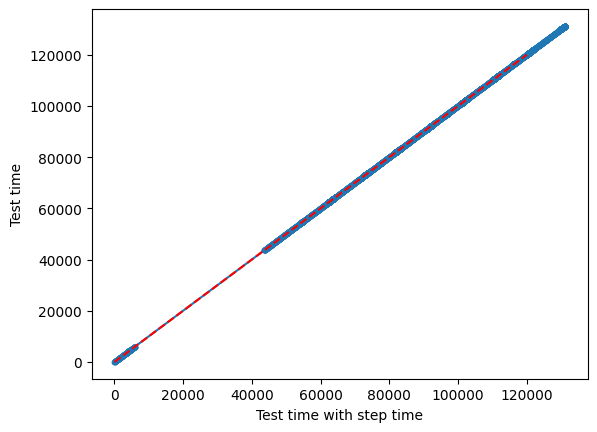

In [111]:
from matplotlib import pyplot as plt
plt.plot((timeser - timeser.iloc[0]).dt.total_seconds(), (pd.to_datetime(df["DPT Time"]) -  pd.to_datetime(df["DPT Time"]).iloc[0]).dt.total_seconds(),'.-')
plt.xlabel("Test time with step time")
plt.ylabel("Test time")
plt.plot([0,120000],[0,120000],'r--')

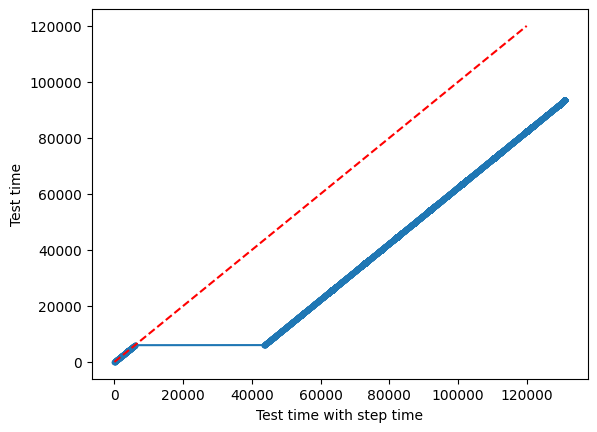

In [112]:
from matplotlib import pyplot as plt
plt.plot((timeser - timeser.iloc[0]).dt.total_seconds(), mcm_transform_reltime(df, ['Test Time', 'Step Time']),'.-')
plt.xlabel("Test time with step time")
plt.ylabel("Test time")
plt.plot([0,120000],[0,120000],'r--')

### Gotion time series func

In [117]:
file_path = Path(r"C:\Users\WYBT00P\OneDrive - Volkswagen AG\C48 Test data - C48T1\Testing_DataBase\x_DataHandling\B2_sample\02_Extracted_Raw_Files\DQ202508003398\DQ202508003398_0℃ 18s.xlsx")

cfg_cls = cfg_got_std_01(file_path)

df = cfg_cls.get_raw_data(etl_df[etl_df['Config_id']=="cfg_got_std_01"].iloc[0])
df

C:\Users\WYBT00P\PycharmProjects\TB_CPA_TestDataAutomation\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,SignNum,StepName,OrgStepNum,LoopNum,StepNum,RecordTime(s),TotalTime(s),Voltage(V),Current(A),AttachTemp1(℃),...,T4(℃),TemperBoxTempPV(℃),TemperBoxHumiPV(%),初始容量(AH),调整容量(AH),调整倍率(1),放电电流(A),充电电流(A),充电容量(AH),工步时间(S)
0,1,ControlStep,1-1,1,1,0.0,0.00,2.6865,0.0,---,...,24.2,24.1,0,0.0000,0.0000,0.0,0,0,0,0
1,2,ControlStep,1-1,1,1,1.0,1.00,2.6865,0.0,---,...,24.2,24.1,0,0.0000,0.0000,0.0,0,0,0,0
2,3,ControlStep,1-1,1,1,2.0,2.00,2.6865,0.0,---,...,24.2,24.1,0,0.0000,0.0000,0.0,0,0,0,0
3,4,ControlStep,1-1,1,1,3.0,3.00,2.6865,0.0,---,...,24.2,24.1,0,0.0000,0.0000,0.0,0,0,0,0
4,5,ControlStep,1-1,1,1,4.0,4.00,2.6865,0.0,---,...,24.2,24.1,0,0.0000,0.0000,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267086,267087,Rest,1-22,10,120,131.0,252403.47,3.3053,0.0,---,...,0.4,0.0,0,218.5106,21.8511,0.1,800,0,0,0
267087,267088,Rest,1-22,10,120,132.0,252404.47,3.3052,0.0,---,...,0.4,0.0,0,218.5106,21.8511,0.1,800,0,0,0
267088,267089,Rest,1-22,10,120,133.0,252405.47,3.3052,0.0,---,...,0.4,0.0,0,218.5106,21.8511,0.1,800,0,0,0
267089,267090,Rest,1-22,10,120,134.0,252406.47,3.3051,0.0,---,...,0.4,0.0,0,218.5106,21.8511,0.1,800,0,0,0


In [149]:

def got_transform_unixtime(file_df:pd.DataFrame, input_columns:list[str])-> pd.Series|None:
    # input 0 is datetime and input 1 is Test time, input 2 is Step time
    # All inputs are in datetime format
    # Tries to pick the first time stamp and add the total seconds to the timestamp

    DPT_Time = pd.to_datetime(file_df[input_columns[0]], errors='coerce')
    if (len(input_columns)>1):
        # try to add timedelta and total seconds caluclated from mcm_transform_reltime() - which considers steptime
        if (input_columns[0] in input_columns) and (input_columns[1] in input_columns):
            test_time = file_df[input_columns[1]]    # total test time in seconds
            rel_time_delta = test_time.diff()  # relative time delta
            abs_time_delta = (DPT_Time - DPT_Time.iloc[0]).dt.total_seconds().diff() #absolute time delta

            for indx in rel_time_delta.loc[(abs_time_delta - rel_time_delta) > 60].index:
                test_time.loc[indx:] = test_time.loc[indx:] + abs_time_delta.loc[indx]

            timeser = DPT_Time.iloc[0] + pd.to_timedelta(test_time, 's')

            if (pd.to_datetime(file_df[input_columns[0]]).iloc[-1] - timeser.iloc[-1]).total_seconds() < 60:
                return timeser
            else:
                logging.info(f"Note @mcm_transform_unixtime() - mismatch in last datetime value, rather using only {input_columns[0]}")

    timeser = pd.to_datetime(file_df[input_columns[0]],errors='coerce')
    return timeser

In [150]:
timeser = got_transform_unixtime(df, ['AbsoluteTime(yyyy-MM-dd HH:mm:ss)', 'TotalTime(s)'])
timeser

0        2025-09-09 09:15:01.000
1        2025-09-09 09:15:02.000
2        2025-09-09 09:15:03.000
3        2025-09-09 09:15:04.000
4        2025-09-09 09:15:05.000
                   ...          
267086   2025-09-12 14:51:51.470
267087   2025-09-12 14:51:52.470
267088   2025-09-12 14:51:53.470
267089   2025-09-12 14:51:54.470
267090   2025-09-12 14:51:55.470
Name: TotalTime(s), Length: 267091, dtype: datetime64[ns]

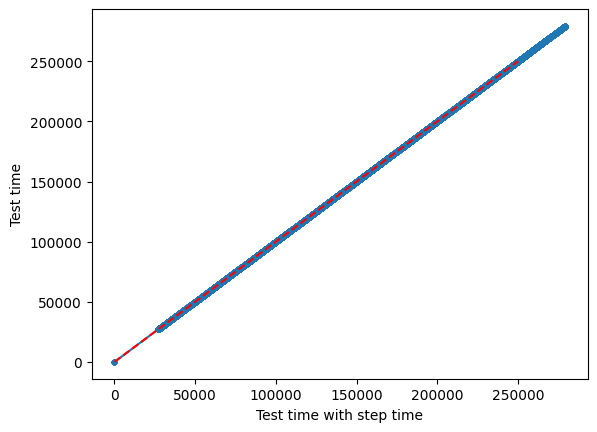

In [151]:
from matplotlib import pyplot as plt
plt.plot((timeser - timeser.iloc[0]).dt.total_seconds(), (pd.to_datetime(df["AbsoluteTime(yyyy-MM-dd HH:mm:ss)"]) -  pd.to_datetime(df["AbsoluteTime(yyyy-MM-dd HH:mm:ss)"]).iloc[0]).dt.total_seconds(),'.-')
plt.xlabel("Test time with step time")
plt.ylabel("Test time")
plt.plot([0,250000],[0,250000],'r--')

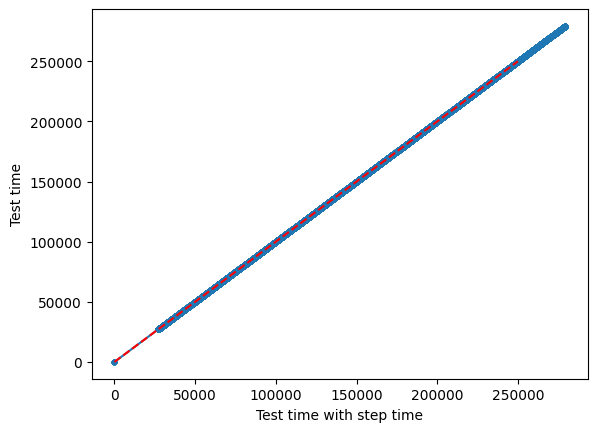

In [152]:
from matplotlib import pyplot as plt
plt.plot((timeser - timeser.iloc[0]).dt.total_seconds(), df["TotalTime(s)"],'.-')
plt.xlabel("Test time with step time")
plt.ylabel("Test time")
plt.plot([0,250000],[0,250000],'r--')

### MCM new format

In [6]:
path = r"C:\Users\WYBT00P\OneDrive - Volkswagen AG\C48 Test data - C48T1\02_CPA_DataBase\x_DataHandling\B1_sample\02_Extracted_Raw_Files\FCA06A0031\20250930_FCA06A0031_CNMCM_C48T_B1_Baseline_RPT_01.xlsx"

In [9]:
df = pd.read_excel(path,sheet_name='RecordInfo')

In [16]:
def parse_d_hms_ms(series: pd.Series) -> pd.Series:
    """
    Convert a Series of strings in 'd.hh:mm:ss.ms' into pandas Timedelta.
    Examples: '0.00:00:30.000', '2.12:05:07', '10.00:00:00.123'
    Non-matching rows become NaT. NaN is preserved.
    """
    # Regex pattern with named groups for clarity
    pat = r'^(?P<days>\d+)\.(?P<hours>\d{2}):(?P<minutes>\d{2}):(?P<seconds>\d{2})(?:\.(?P<msecs>\d+))?$'

    # Extract components
    parts = series.astype('string').str.extract(pat)

    # If nothing matches, return all-NaT Series of same index
    if parts.isna().all(axis=None):
        return pd.Series(pd.NaT, index=series.index, dtype='timedelta64[ns]')

    # Convert each component to numeric; missing msecs -> 0
    days    = pd.to_numeric(parts['days'], errors='coerce').fillna(0)
    hours   = pd.to_numeric(parts['hours'], errors='coerce').fillna(0)
    minutes = pd.to_numeric(parts['minutes'], errors='coerce').fillna(0)
    seconds = pd.to_numeric(parts['seconds'], errors='coerce').fillna(0)
    msecs   = pd.to_numeric(parts['msecs'], errors='coerce').fillna(0)

    # Build timedelta vectorized
    td = (
        pd.to_timedelta(days,    unit='D') +
        pd.to_timedelta(hours,   unit='h') +
        pd.to_timedelta(minutes, unit='m') +
        pd.to_timedelta(seconds, unit='s') +
        pd.to_timedelta(msecs,   unit='ms')
    )

    # Merge back: rows that didn't match the pattern become NaT
    matched = series.astype('string').str.match(pat, na=False)
    out = pd.Series(pd.NaT, index=series.index, dtype='timedelta64[ns]')
    out.loc[matched] = td.loc[matched].values
    return out

C:\Users\WYBT00P\AppData\Local\Temp\ipykernel_35640\1601458993.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


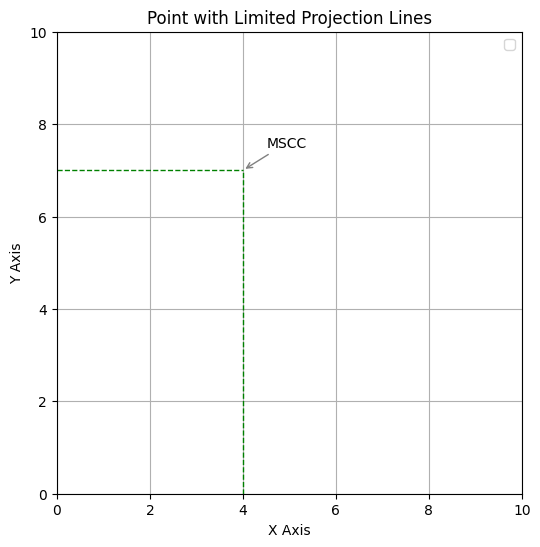

In [72]:

import matplotlib.pyplot as plt

# Coordinates of the point
x_val, y_val = 4, 7

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))


# Projection lines limited to the point
ax.plot([x_val, x_val], [0, y_val], color='green', linestyle='--', linewidth=1)  # vertical line
ax.plot([0, x_val], [y_val, y_val], color='green', linestyle='--', linewidth=1)  # horizontal line

# Annotate the point
ax.annotate(f'MSCC', xy=(x_val, y_val), xytext=(x_val+0.5, y_val+0.5),
            arrowprops=dict(arrowstyle='->', color='gray'))

# Set limits and labels
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_title('Point with Limited Projection Lines')
ax.grid(True)
ax.legend()

plt.show()


In [3]:
import os
import re

def get_base_name(filename):
    # Extract base name before the optional _copy# suffix and extension
    # e.g. filename_copy1.xlsx -> filename
    pattern = r"^(.*?)(?:_copy\d+)?(\.[^.]*)$"
    match = re.match(pattern, filename)
    if match:
        return match.group(1), match.group(2)  # base name, extension
    return filename, ''

def remove_smaller_copies(directory):
    files = os.listdir(directory)
    grouped_files = {}

    for f in files:
        base_name, ext = get_base_name(f)
        if ext:  # consider only files with extensions
            key = base_name + ext
            grouped_files.setdefault(key, []).append(f)

    for base, file_list in grouped_files.items():
        if len(file_list) > 1:
            # Compare sizes, keep the largest
            sizes = [(fname, os.path.getsize(os.path.join(directory, fname))) for fname in file_list]
            sizes.sort(key=lambda x: x[1], reverse=True)
            # Keep largest file, remove others
            largest_file = sizes[0][0]
            for fname, size in sizes[1:]:
                os.remove(os.path.join(directory, fname))
                print(f"Removed smaller copy: {fname}")



In [13]:
folder_path = Path(r"C:\Users\WYBT00P\OneDrive - Volkswagen AG\C48 Test data - C48T1\02_CPA_DataBase\x_DataHandling\Benchmark\03_Harmonized_Data\FCA02A0139")

get_base_name("20250702_FCA02A0139_CNMCM_C48T_B1_Baseline_RPT_00_copy.csv")

('20250702_FCA02A0139_CNMCM_C48T_B1_Baseline_RPT_00_copy', '.csv')

In [46]:
from matplotlib import pyplot as plt
import numpy as np

In [19]:
def got_transform_unixtime(file_df:pd.DataFrame, input_columns:list[str])-> pd.Series|None:
    # input 0 is Absolute time, input 1 is TotalTime(s)
    # Tries to pick the first time stamp and add the total seconds to the timestamp, after gap correction

    DPT_Time = pd.to_datetime(file_df[input_columns[0]], errors='coerce')
    if (len(input_columns)>1):
        # try to add timedelta and total seconds caluclated from mcm_transform_reltime() - which considers steptime
        if (input_columns[0] in input_columns) and (input_columns[1] in input_columns):

            test_time = file_df[input_columns[1]]    # total test time in seconds
            rel_time_delta = test_time.diff()  # relative time delta
            abs_time_delta = (DPT_Time - DPT_Time.iloc[0]).dt.total_seconds().diff() #absolute time delta

            for indx in rel_time_delta.loc[(abs_time_delta - rel_time_delta) > 60].index:
                test_time.loc[indx:] = test_time.loc[indx:] + abs_time_delta.loc[indx]

            timeser = DPT_Time.iloc[0] + pd.to_timedelta(test_time, 's')

            if (pd.to_datetime(file_df[input_columns[0]]).iloc[-1] - timeser.iloc[-1]).total_seconds() < 60:
                return timeser
            else:
                logging.info(f"Note @mcm_transform_unixtime() - mismatch in last datetime value, rather using only {input_columns[0]}")

    timeser = pd.to_datetime(file_df[input_columns[0]],errors='coerce')
    return timeser

def convert_timestamp(x):
    # convert datetime to unix time format
    try:
        return x.timestamp()
    except:
        return None

def gen_calc_unix(file_df: pd.DataFrame)->pd.Series|None:
    if 'Date_time' in file_df.columns:
        return file_df['Date_time'].apply(convert_timestamp)
    else:
        return None

In [11]:
filepath = Path(r"C:\Users\WYBT00P\OneDrive - Volkswagen AG\C48 Test data - C48T1\02_CPA_DataBase\x_DataHandling\A1_sample\02_Extracted_Raw_Files\DQ202506004599\DQ202506004599_capacity test.xlsx")
filedf = pd.read_excel(filepath,sheet_name='RecordInfo')

In [25]:
timesr = got_transform_unixtime(file_df=filedf, input_columns=["AbsoluteTime(yyyy-MM-dd HH:mm:ss)","TotalTime(s)"])
print(timesr.iloc[7299:7305].values)

['2025-08-04T19:19:34.000000000' '2025-08-04T19:19:34.480000000'
 '2025-08-04T19:19:34.480000000' '2025-08-04T19:19:35.480000000'
 '2025-08-04T19:19:36.480000000' '2025-08-04T19:19:37.480000000']


In [2]:
path = Path(r"C:\Users\WYBT00P\OneDrive - Volkswagen AG\C48 Test data - C48T1\02_CPA_DataBase\x_DataHandling\B2_sample\02_Extracted_Raw_Files\FCADOE5023\20251122_FCADOE5023_CNMCM_C48T B2 DOE5_RPT_00.xlsx")

file_df = pd.read_excel(path,sheet_name='RecordInfo')
input_column = ["TotalTime(d.hh:mm:ss.sss)"]
if "d.h" in input_column[0]:
    step_time_series = pd.to_timedelta(parse_d_hms_ms(file_df[input_column[0]])).dt.total_seconds()

step_time_series


0             0.00
1            30.00
2            60.00
3            90.00
4           120.00
           ...    
57475    124710.14
57476    124710.24
57477    124710.34
57478    124710.44
57479    124710.54
Length: 57480, dtype: float64